<a href="https://www.kaggle.com/code/dmytrokan/data-set?scriptVersionId=353952148" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Ознайомитись з даними та структурою даних
Створіть доповнення(transform) для тренувальних та тестових даних. посилання
Створіть train_dataset та test_dataset за допомогою ImageFolder
Створіть DataLoader
Візуалізуйте дані
Збережіть kaggle notebook для подальшої роботи

In [35]:
from torchvision import datasets, transforms

In [36]:
paths = "/kaggle/input/datasets/yapwh1208/cats-breed-dataset/cat_v1"

In [37]:
dataset = datasets.ImageFolder(paths)

In [38]:
img, label = dataset[30]

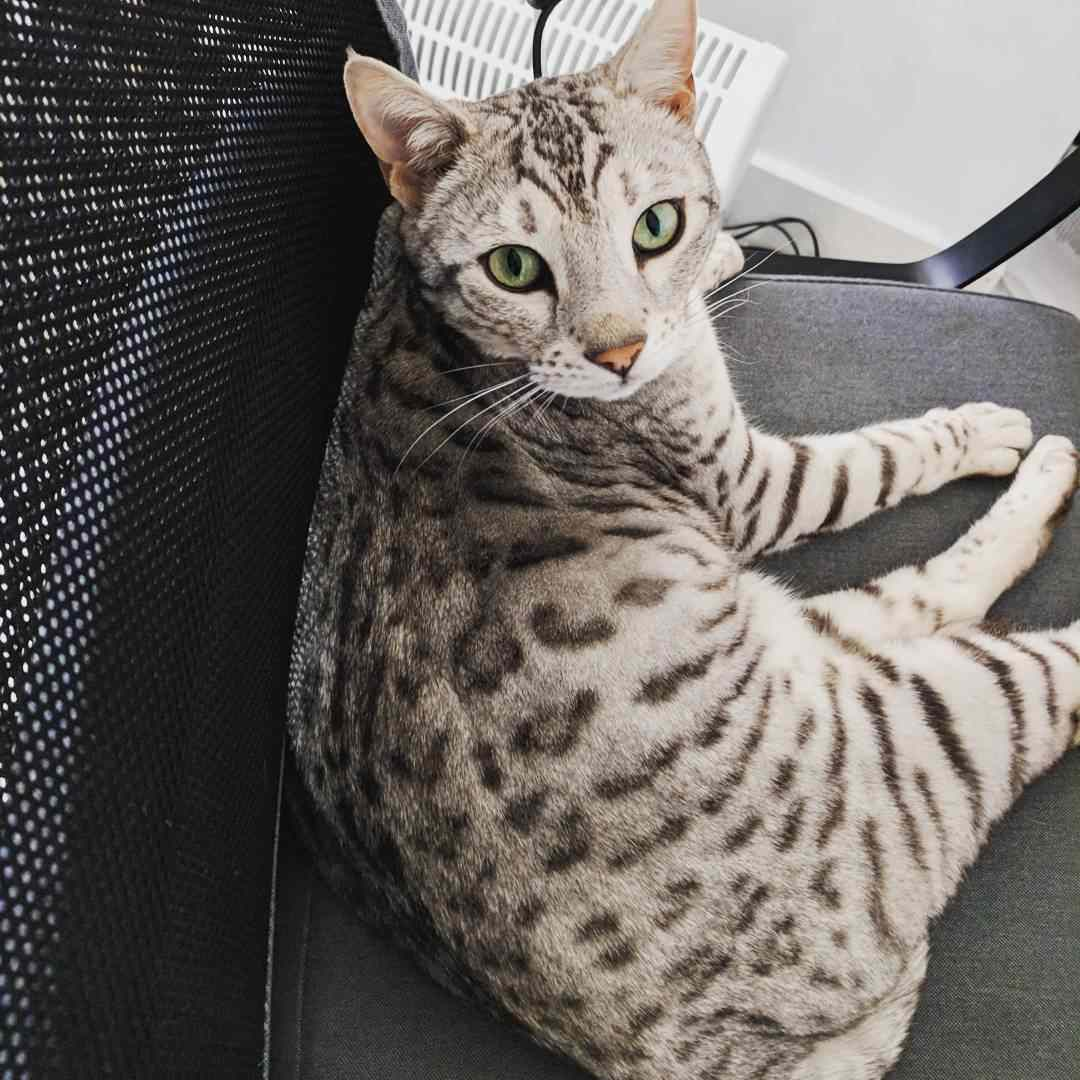

In [39]:
img

In [40]:
label

0

In [41]:
dataset.classes[label]

'bengal'

In [42]:
from torch.utils.data import random_split

train_dataset, test_dataset = random_split(dataset, [0.8, 0.2])

In [43]:
from torchvision import transforms
train_transformer = transforms.Compose([
       transforms.Resize([256, 256]), 
       transforms.RandomHorizontalFlip(p=0.5),  
       transforms.RandomRotation(10),   
       transforms.ToTensor()  
])

test_transformer = transforms.Compose([
       transforms.Resize([256, 256]),
       transforms.ToTensor()
])

In [50]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [49]:

train_dataset = TransformDataset(train_dataset, train_transformer)
test_dataset = TransformDataset(test_dataset, test_transformer)

In [46]:
train_dataset[0]

(tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.5765, 0.4784, 0.0000],
          [0.9569, 0.9569, 0.9647,  ..., 0.4157, 0.4157, 0.0000],
          [0.9608, 0.9608, 0.9647,  ..., 0.4000, 0.4078, 0.0000],
          ...,
          [0.0000, 0.1569, 0.1451,  ..., 0.2510, 0.2353, 0.2392],
          [0.0000, 0.1529, 0.1490,  ..., 0.2392, 0.2078, 0.2314],
          [0.0000, 0.1647, 0.1647,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0000, 0.0000, 0.0000,  ..., 0.6353, 0.5686, 0.0000],
          [0.9765, 0.9725, 0.9765,  ..., 0.4824, 0.4863, 0.0000],
          [0.9804, 0.9765, 0.9765,  ..., 0.4706, 0.4588, 0.0000],
          ...,
          [0.0000, 0.2118, 0.1961,  ..., 0.3412, 0.3333, 0.3098],
          [0.0000, 0.2157, 0.2039,  ..., 0.3216, 0.3216, 0.3098],
          [0.0000, 0.2039, 0.2157,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0000, 0.0000, 0.0000,  ..., 0.5843, 0.4235, 0.0000],
          [0.9922, 0.9922, 0.9961,  ..., 0.3529, 0.3373, 0.0000],
          [0.9961, 0.9961, 0.9961,  ...,

In [51]:
train_loader = DataLoader(train_dataset, batch_size = 20)
test_loader = DataLoader(test_dataset, batch_size = 20)